# UN M7 — equazioni implementate

$$
D_g = D_1 + D_3
$$

$$
D_1 = D_{10}\exp\left(-\frac{Q_1}{k_BT}\right)
$$

$$
D_3 = A_{30}\dot F
$$

$$
D_v = D_{v,1}+D_{v,2}
$$

$$
D_{v,1}=D_{10}^{v}\exp\left(-\frac{Q_1^v}{k_BT}\right)
$$

$$
D_{v,2}=\sqrt{\dot F}\,A_{20}^{v,refit}
\exp\left(
\frac{B_{21}^{v}}{k_BT}
+
\frac{B_{22}^{v}}{(k_BT)^2}
\right)
$$

$$
\beta=Y_{Xe}\dot F
$$

$$
\nu_b=8\pi f_nD_g\Omega_{fg}^{1/3}c^2
$$

$$
b_i=b_0(R_i)\dot F,\qquad i=b,d
$$

$$
b_0(R)=10^{-25}\left(2.64-2.02\exp\left[-\frac{2.61\times10^{-9}}{R}\right]\right)
$$

$$
g_b=4\pi D_gR_bN_b
$$

$$
\Gamma_d=\frac{1}{\sqrt{\pi\rho_d}}
$$

$$
g_d=4\pi D_gR_dN_d+
\frac{2\pi D_g}{\ln\left(\frac{\Gamma_d}{Z_dr_d}\right)-\frac35}
\left(\rho_d-2R_dN_d\right)
$$

$$
\phi_b=\frac{1}{m_b/N_b-1}
$$

$$
\phi_d=\frac{1}{m_d/N_d-1}
$$

$$
b_b^{gas}=b_b\phi_b
$$

$$
b_d^{gas}=b_d\phi_d
$$

$$
\frac{\partial c}{\partial t}
=
D_g\nabla^2c
-(g_b+g_d)c
+b_b^{gas}m_b
+b_d^{gas}m_d
+\beta
-2\nu_b
$$

$$
\frac{\partial m_b}{\partial t}
=
g_bc-b_b^{gas}m_b+2\nu_b
$$

$$
\frac{\partial m_d}{\partial t}
=
g_dc-b_d^{gas}m_d
$$

$$
\frac{\partial N_b}{\partial t}=\nu_b-b_b\phi_bN_b
$$

$$
\lambda_d=\frac{2-\xi_d}{2(1-\xi_d)^3}
$$

$$
\xi_d=V_dN_d
$$

$$
\frac{\partial N_d}{\partial t}=-4\lambda_dN_d^2\frac{dV_d}{dt}
$$

$$
p_i=\frac{k_BT\,m_i}{n_i\Omega},\qquad i=b,d
$$

$$
p_{i,eq}=\frac{2\gamma}{R_i}-\sigma_h
$$

$$
\delta_i=\left(\frac{3}{4\pi N_i}\right)^{1/3}
$$

$$
\psi_i=\frac{R_i}{\delta_i}
$$

$$
\zeta_i=\frac{10\psi_i(1+\psi_i^3)}{-\psi_i^6+5\psi_i^2-9\psi_i+5}
$$

$$
\frac{dn_i}{dt}=
\frac{2\pi D_v\delta_iN_i}{k_BT\zeta_i}
\left(p_i-p_{i,eq}\right),\qquad i=b,d
$$

$$
V_i=\frac{\Omega_{fg}m_i+\Omega n_i}{N_i},\qquad i=b,d
$$

$$
R_i=\left(\frac{3V_i}{4\pi}\right)^{1/3},\qquad i=b,d
$$

$$
V_{cap}=\frac{4\pi}{3}(R_b+R_d)^3
$$

$$
f_{cap}=\min\left[1,\max\left(0,N_d\Delta V_{cap}\right)\right]
$$

$$
N_b^+=(1-f_{cap})N_b^-
$$

$$
m_b^+=(1-f_{cap})m_b^-
$$

$$
m_d^+=m_d^-+f_{cap}m_b^-
$$

$$
n_b^+=(1-f_{cap})n_b^-
$$

$$
n_d^+=n_d^-+f_{cap}n_b^-
$$

$$
\left(\frac{\Delta V}{V}\right)_b=N_bV_b
$$

$$
\left(\frac{\Delta V}{V}\right)_d=N_dV_d
$$


In [3]:
# UN M7 PARAMETER SWEEP - complete notebook cell / standalone script
#
# Physics: M7 = nucleation gas mass coupling + phi re-solution
#             + bulk-dislocation capture.
# Purpose: fast parameter sensitivity and coarse calibration against Rizk Fig. 3, 7, 8.
#
# Recommended workflow:
# 1) Run this cell as-is for a FAST sweep: DT=24 h, n_modes=15.
# 2) Inspect results_M7_sweep/summary.md and the printed best candidates.
# 3) Increase N_RANDOM_CANDIDATES if needed.
# 4) Only final candidates are recomputed with DT=1 h, n_modes=40.
#
# The code is self-contained: paste into a blank notebook cell and run.
# ============================================================

import csv
import math
import os
import random
from dataclasses import dataclass, replace
from typing import Optional, Sequence, Dict, List, Tuple, Any

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None

# ============================================================
# USER CONFIGURATION
# ============================================================

OUTPUT_DIR = "results_M7_sweep"
RANDOM_SEED = 12345

# FAST sweep numerics. This was checked against 1 h / 40 modes and gave similar trends.
FAST_DT_H = 24.0
FAST_N_MODES = 15

# FINAL rerun numerics for only the best candidates.
FINAL_DT_H = 1.0
FINAL_N_MODES = 40
N_FINALISTS = 6

# Random sweep size. Increase to 300-500 if you leave it running longer.
N_RANDOM_CANDIDATES = 180

RUN_OAT_SENSITIVITY = True
RUN_RANDOM_SWEEP = True
RUN_FINAL_RERUN = True
MAKE_PLOTS = True
SAVE_FIGS = True

# Nominal Rizk-like constants.
NOMINAL_FISSION_RATE = 5.0e19          # fissions / (m3 s), approx validation value used in UNmodel.md
NOMINAL_GRAIN_RADIUS = 6.0e-6          # m
NOMINAL_XE_YIELD = 0.24                # Xe atoms/fission
NOMINAL_F_N = 1.0e-6                   # Rizk nominal, inherited from U3Si2
NOMINAL_K_D = 5.0e5                    # bubble/m, Rizk nominal K
NOMINAL_RHO_D = 3.0e13                 # m^-2
NOMINAL_G_D_SCALE = 1.0
NOMINAL_BULK_SEED_RADIUS_NM = 0.0

# Capture law:
# - "exp" is continuous: f = 1-exp(-raw), never above 1.
# - "clamp" is old discrete approximation: f = min(raw,1).
CAPTURE_LAW = "exp"

# ============================================================
# SWEEP RANGES
# ============================================================

# Direct physical / uncertain parameters.
GRID_F_N = [1e-8, 3e-8, 1e-7, 3e-7, 1e-6, 3e-6]
GRID_K_D = [2e5, 3e5, 5e5, 8e5, 1.2e6]
GRID_RHO_D = [1e13, 3e13, 6e13, 1e14]
GRID_FISSION_RATE = [2.5e19, 3.5e19, 5.0e19, 7.5e19, 1.0e20]

# Multipliers on model terms. These are diagnostic/calibration knobs, not original Rizk parameters.
GRID_DG_SCALE = [0.3, 0.5, 1.0, 2.0, 3.0]
GRID_DV_SCALE = [0.3, 1.0, 3.0]
GRID_B_SCALE = [0.3, 0.5, 1.0, 2.0, 3.0]
GRID_GB_SCALE = [0.1, 0.3, 0.5, 1.0]
GRID_GD_SCALE = [0.5, 1.0, 2.0, 3.0]
GRID_NU_SCALE = [0.3, 1.0, 3.0]
GRID_COALESCENCE_D_SCALE = [0.0, 0.3, 1.0, 3.0, 10.0]
GRID_CAPTURE_SCALE = [0.0, 0.1, 0.3, 1.0, 3.0]

# Score weights. Fig. 3 P2/dislocation swelling is the main target.
W_SWELLING_D = 1.0
W_RD_LOG = 1.0
W_ND_LOG = 1.0
W_PRESSURE = 0.20
W_HIGHT_DIAG = 0.05

# ============================================================
# DIGITIZED EXPERIMENTAL POINTS
# ============================================================

EXP_SWELLING_T = [
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1127.0, "swelling": 0.68},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1228.0, "swelling": 0.59},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1312.0, "swelling": 0.43},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1402.0, "swelling": 0.58},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1485.0, "swelling": 1.22},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1549.0, "swelling": 1.84},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1598.0, "swelling": 1.66},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1632.0, "swelling": 2.13},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1669.0, "swelling": 3.60},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1685.0, "swelling": 2.72},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 899.0,  "swelling": 0.63},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1154.0, "swelling": 1.17},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1228.0, "swelling": 1.08},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1325.0, "swelling": 1.28},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1435.0, "swelling": 1.32},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1514.0, "swelling": 2.10},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1570.0, "swelling": 2.72},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1608.0, "swelling": 2.91},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1635.0, "swelling": 3.28},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1656.0, "swelling": 3.75},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1044.0, "swelling": 1.11},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1220.0, "swelling": 1.22},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1377.0, "swelling": 1.33},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1534.0, "swelling": 2.83},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1595.0, "swelling": 3.53},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1639.0, "swelling": 3.86},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1661.0, "swelling": 2.45},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1709.0, "swelling": 2.93},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1724.0, "swelling": 3.15},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 984.0,  "swelling": 0.72},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1056.0, "swelling": 1.06},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1126.0, "swelling": 1.26},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1247.0, "swelling": 1.58},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1343.0, "swelling": 1.79},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1420.0, "swelling": 2.08},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1459.0, "swelling": 2.40},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1511.0, "swelling": 2.83},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1557.0, "swelling": 3.31},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1590.0, "swelling": 3.75},
]

EXP_SWELLING_BURNUP_1600 = [
    {"burnup": 1.12, "swelling": 1.64, "series": "approx 100 kW/m"},
    {"burnup": 1.11, "swelling": 2.90, "series": "approx 119 kW/m"},
    {"burnup": 1.31, "swelling": 3.51, "series": "measurement"},
    {"burnup": 3.18, "swelling": 3.72, "series": "measurement"},
]

EXP_ND_T_13 = [
    {"T": 1153.0, "N": 5.22e19}, {"T": 1202.0, "N": 3.69e19},
    {"T": 1227.0, "N": 3.00e19}, {"T": 1235.0, "N": 3.57e19},
    {"T": 1248.0, "N": 2.44e19}, {"T": 1330.0, "N": 2.90e19},
    {"T": 1338.0, "N": 4.10e19}, {"T": 1377.0, "N": 2.71e19},
    {"T": 1408.0, "N": 1.67e19}, {"T": 1427.0, "N": 1.85e19},
    {"T": 1493.0, "N": 3.00e19}, {"T": 1507.0, "N": 2.44e19},
    {"T": 1524.0, "N": 1.56e19}, {"T": 1538.0, "N": 7.54e18},
    {"T": 1555.0, "N": 7.80e18}, {"T": 1561.0, "N": 1.92e19},
    {"T": 1599.0, "N": 5.34e18}, {"T": 1622.0, "N": 7.80e18},
    {"T": 1628.0, "N": 1.73e19}, {"T": 1649.0, "N": 5.34e18},
    {"T": 1656.0, "N": 3.65e18}, {"T": 1656.0, "N": 2.41e18},
    {"T": 1669.0, "N": 1.96e18}, {"T": 1682.0, "N": 2.44e19},
    {"T": 1685.0, "N": 1.40e19}, {"T": 1723.0, "N": 7.70e17},
    {"T": 1742.0, "N": 1.02e18}, {"T": 1739.0, "N": 1.65e18},
]

# Lighter representative subset for fast scoring. Full set is still plotted/available.
EXP_ND_T_13_SCORE = EXP_ND_T_13[::2]

EXP_RD_T_13 = [
    {"T": 1045.0, "R_nm": 54.06}, {"T": 1219.0, "R_nm": 60.37},
    {"T": 1374.0, "R_nm": 69.58}, {"T": 1535.0, "R_nm": 104.85},
    {"T": 1594.0, "R_nm": 120.83}, {"T": 1641.0, "R_nm": 143.73},
    {"T": 1663.0, "R_nm": 122.76}, {"T": 1710.0, "R_nm": 157.99},
    {"T": 1725.0, "R_nm": 173.67},
]

# Fig. 3 score: use P2/dislocation comparison only; keep T <= 1700 K.
EXP_SWELLING_SCORE = [p for p in EXP_SWELLING_T if p["T"] <= 1700.0]

# ============================================================
# MODEL PARAMETERS AND HELPER FUNCTIONS
# ============================================================

@dataclass(frozen=True)
class Candidate:
    label: str = "candidate"
    f_n: float = NOMINAL_F_N
    K_d: float = NOMINAL_K_D
    rho_d: float = NOMINAL_RHO_D
    fission_rate: float = NOMINAL_FISSION_RATE
    Dg_scale: float = 1.0
    Dv_scale: float = 1.0
    b_scale: float = 1.0
    gb_scale: float = 1.0
    gd_scale: float = 1.0
    nu_scale: float = 1.0
    coalescence_d_scale: float = 1.0
    capture_scale: float = 1.0
    bulk_seed_radius_nm: float = NOMINAL_BULK_SEED_RADIUS_NM

    def as_dict(self) -> Dict[str, Any]:
        return self.__dict__.copy()

@dataclass
class UNParameters:
    temperature: float = 1600.0
    fission_rate: float = NOMINAL_FISSION_RATE
    grain_radius: float = NOMINAL_GRAIN_RADIUS
    target_burnup_percent_fima: Optional[float] = None
    final_time: float = 24.0 * 3600.0
    dt: float = FAST_DT_H * 3600.0
    n_modes: int = FAST_N_MODES

    xe_yield: float = NOMINAL_XE_YIELD
    precursor_factor: float = 1.0

    D10: float = 1.56e-3
    Q1: float = 4.94
    A30: float = 1.85e-39
    kB_eV: float = 8.617333262e-5
    kB_J: float = 1.380649e-23

    # Vacancy diffusivity: thermal term from Rizk; irradiation term refitted to Rizk Fig. 4 scale.
    D10_vU: float = 1.35e-2
    Q1_vU: float = 5.66
    B21_vU_refit: float = -0.62
    B22_vU_refit: float = -0.04
    A20_vU_fig4_refit: float = 4.6304523933553033e-29

    radius_in_lattice: float = 0.21e-9
    omega_fg: float = 8.5e-29
    lattice_parameter: float = 4.889e-10
    gamma_b: float = 1.11
    hydrostatic_stress: float = 0.0
    min_radius_for_pressure: float = 1.0e-15

    f_n: float = NOMINAL_F_N
    rho_d: float = NOMINAL_RHO_D
    K_d: float = NOMINAL_K_D
    r_d: float = 3.46e-10
    Z_d: float = 5.0

    Dg_scale: float = 1.0
    Dv_scale: float = 1.0
    b_scale: float = 1.0
    gb_scale: float = 1.0
    gd_scale: float = 1.0
    nu_scale: float = 1.0
    coalescence_d_scale: float = 1.0
    capture_scale: float = 1.0

    R_b: float = 0.0
    N_b: float = 0.0
    R_d: float = 0.0
    N_d: Optional[float] = None
    c0: float = 0.0
    mb0: float = 0.0
    md0: float = 0.0
    nvb0: Optional[float] = None
    nvd0: Optional[float] = None

    bulk_seed_radius_nm: float = NOMINAL_BULK_SEED_RADIUS_NM
    vacancy_absorption_only: bool = True
    update_bulk_vacancies: bool = True
    min_number_density: float = 0.0
    min_volume: float = 0.0

    def __post_init__(self):
        if self.N_d is None:
            self.N_d = self.K_d * self.rho_d
        if self.target_burnup_percent_fima is not None:
            self.final_time = burnup_percent_to_time(
                self.target_burnup_percent_fima,
                self.fission_rate,
                self.lattice_parameter,
            )


def omega_matrix(p: UNParameters) -> float:
    return p.lattice_parameter**3 / 4.0


def uranium_atom_density_from_lattice(lattice_parameter: float) -> float:
    return 4.0 / lattice_parameter**3


def burnup_percent_to_time(burnup_percent_fima: float, fission_rate: float, lattice_parameter: float) -> float:
    if fission_rate <= 0.0:
        raise ValueError("fission_rate must be positive")
    return (burnup_percent_fima / 100.0) * uranium_atom_density_from_lattice(lattice_parameter) / fission_rate


def time_to_burnup_percent(time: float, fission_rate: float, lattice_parameter: float) -> float:
    return 100.0 * fission_rate * time / uranium_atom_density_from_lattice(lattice_parameter)


def sphere_volume(R: float) -> float:
    return 0.0 if R <= 0.0 else (4.0 / 3.0) * math.pi * R**3


def radius_from_volume(V: float) -> float:
    return 0.0 if V <= 0.0 else (3.0 * V / (4.0 * math.pi)) ** (1.0 / 3.0)


def xe_diffusivity_UN(p: UNParameters):
    T = p.temperature
    kBT = p.kB_eV * T
    D1 = p.D10 * math.exp(-p.Q1 / kBT)
    D3 = p.A30 * p.fission_rate
    Dg_unscaled = (D1 + D3) * p.precursor_factor
    Dg = p.Dg_scale * Dg_unscaled
    return Dg, {"D1": D1, "D3": D3, "Dg_unscaled": Dg_unscaled, "Dg": Dg}


def vacancy_diffusivity_UN(p: UNParameters):
    T = p.temperature
    kBT = p.kB_eV * T
    D1 = p.D10_vU * math.exp(-p.Q1_vU / kBT)
    D2 = math.sqrt(p.fission_rate) * p.A20_vU_fig4_refit * math.exp(
        p.B21_vU_refit / kBT + p.B22_vU_refit / (kBT**2)
    )
    Dv_unscaled = D1 + D2
    Dv = p.Dv_scale * Dv_unscaled
    return Dv, {"Dv1": D1, "Dv2": D2, "Dv_unscaled": Dv_unscaled, "Dv": Dv}


def b0_resolution(R: float) -> float:
    R = max(R, 1.0e-15)
    return 1.0e-25 * (2.64 - 2.02 * math.exp(-2.61e-9 / R))


def resolution_rates_UN(p: UNParameters, R_b: float, R_d: float):
    b_b_unscaled = p.fission_rate * b0_resolution(R_b + p.radius_in_lattice)
    b_d_unscaled = p.fission_rate * b0_resolution(R_d + p.radius_in_lattice)
    b_b = p.b_scale * b_b_unscaled
    b_d = p.b_scale * b_d_unscaled
    return b_b, b_d, {"b_b_unscaled": b_b_unscaled, "b_d_unscaled": b_d_unscaled}


def trapping_rates_UN(p: UNParameters, Dg: float, R_b: float, N_b: float, R_d: float, N_d: float):
    Rb_eff = R_b + p.radius_in_lattice
    Rd_eff = R_d + p.radius_in_lattice
    g_b_unscaled = 0.0 if N_b <= 0.0 else 4.0 * math.pi * Dg * Rb_eff * N_b

    Gamma_d = 1.0 / math.sqrt(math.pi * p.rho_d)
    den = math.log(Gamma_d / (p.Z_d * p.r_d)) - 3.0 / 5.0
    if den <= 0.0:
        raise ValueError(f"Invalid dislocation sink denominator: {den:g}")
    free_dislocation = max(p.rho_d - 2.0 * R_d * N_d, 0.0)
    term_bubbles = 4.0 * math.pi * Dg * Rd_eff * N_d
    term_dislocation = (2.0 * math.pi * Dg / den) * free_dislocation
    g_d_unscaled = term_bubbles + term_dislocation
    g_b = p.gb_scale * g_b_unscaled
    g_d = p.gd_scale * g_d_unscaled
    return g_b, g_d, {
        "Gamma_d": Gamma_d,
        "den": den,
        "free_dislocation": free_dislocation,
        "term_bubbles": term_bubbles,
        "term_dislocation": term_dislocation,
        "g_b_unscaled": g_b_unscaled,
        "g_d_unscaled": g_d_unscaled,
    }


def beta_production(p: UNParameters) -> float:
    return p.xe_yield * p.fission_rate


def nucleation_rate_bulk(p: UNParameters, Dg: float, c: float) -> float:
    nu = 8.0 * math.pi * p.f_n * Dg * p.omega_fg ** (1.0 / 3.0) * max(c, 0.0) ** 2
    return p.nu_scale * nu


def phi_population(m_gas: float, N: float) -> float:
    if N <= 0.0 or m_gas <= 0.0:
        return 0.0
    atoms_per_bubble = m_gas / N
    if atoms_per_bubble <= 1.0:
        return 0.0
    return 1.0 / (atoms_per_bubble - 1.0)


def coalescence_lambda(Vd: float, Nd: float) -> float:
    xi = max(0.0, min(Vd * Nd, 0.999999))
    return (2.0 - xi) / (2.0 * (1.0 - xi) ** 3)


def pressure_internal(p: UNParameters, m_gas: float, n_vac: float) -> float:
    if m_gas <= 0.0:
        return 0.0
    if n_vac <= 0.0:
        return math.inf
    denom = n_vac * omega_matrix(p)
    return math.inf if denom <= 0.0 else p.kB_J * p.temperature * m_gas / denom


def pressure_equilibrium(p: UNParameters, R: float) -> float:
    return 2.0 * p.gamma_b / max(R, p.min_radius_for_pressure) - p.hydrostatic_stress


def gas_only_radius_for_population(p: UNParameters, m_gas: float, N: float) -> float:
    if m_gas <= 0.0 or N <= 0.0:
        return 0.0
    return radius_from_volume(p.omega_fg * m_gas / N)


def radius_for_vacancy_update(p: UNParameters, R_old: float, N: float, m_gas: float) -> float:
    if R_old > 0.0:
        return R_old
    return gas_only_radius_for_population(p, m_gas, N)


def wigner_seitz_delta(N: float) -> float:
    return (3.0 / (4.0 * math.pi * max(N, 1.0))) ** (1.0 / 3.0)


def zeta_geometry(R: float, N: float) -> float:
    delta = wigner_seitz_delta(N)
    psi = max(R / delta, 1.0e-12)
    den = -psi**6 + 5.0 * psi**2 - 9.0 * psi + 5.0
    den = max(den, 1.0e-30)
    return max(10.0 * psi * (1.0 + psi**3) / den, 1.0e-30)


def vacancy_concentration_implicit_step(p: UNParameters, Dv: float, R: float, N: float, m_gas: float, n_old: float, dt: float):
    if N <= 0.0 or m_gas <= 0.0:
        return n_old, 0.0
    R_update = radius_for_vacancy_update(p, R, N, m_gas)
    if R_update <= 0.0:
        return n_old, 0.0
    p_eq = 2.0 * p.gamma_b / R_update - p.hydrostatic_stress
    p_int_old = pressure_internal(p, m_gas, n_old)
    if p.vacancy_absorption_only and p_int_old <= p_eq:
        return n_old, 0.0
    delta = wigner_seitz_delta(N)
    zeta = zeta_geometry(R_update, N)
    A = 2.0 * math.pi * Dv * delta * N / (p.kB_J * p.temperature * zeta)
    C = p.kB_J * p.temperature * m_gas / omega_matrix(p)
    B = n_old - dt * A * p_eq
    disc = B * B + 4.0 * dt * A * C
    if disc < 0.0:
        raise ValueError(f"Negative discriminant in vacancy step: {disc:g}")
    sqrt_disc = math.sqrt(disc)
    if B >= 0.0:
        n_new = 0.5 * (B + sqrt_disc)
    else:
        denom = sqrt_disc - B
        n_new = 0.0 if denom <= 0.0 else (2.0 * dt * A * C) / denom
    if p.vacancy_absorption_only:
        n_new = max(n_new, n_old)
    return n_new, (n_new - n_old) / dt


def initialize_vacancy_concentration(p: UNParameters, N: float, R: float, m_gas: float) -> float:
    if N <= 0.0 or R <= 0.0:
        return 0.0
    vacancy_volume = max(N * sphere_volume(R) - p.omega_fg * m_gas, 0.0)
    return vacancy_volume / omega_matrix(p)


def initialize_modes_from_average(average: float, n_modes: int, n_iter: int = 20):
    modes = [0.0 for _ in range(n_modes)]
    projection_coeff = -math.sqrt(8.0 / math.pi)
    remainder = average
    for _ in range(n_iter):
        reconstructed = 0.0
        for i in range(n_modes):
            n = i + 1
            n_coeff = (-1.0) ** n / n
            modes[i] += projection_coeff * n_coeff * remainder
            reconstructed += projection_coeff * n_coeff * modes[i] * 3.0 / (4.0 * math.pi)
        remainder = average - reconstructed
    return modes


def reconstruct_average(modes: Sequence[float]) -> float:
    projection_coeff = -2.0 * math.sqrt(2.0 / math.pi)
    average = 0.0
    for i, value in enumerate(modes):
        n = i + 1
        n_coeff = (-1.0) ** n / n
        average += projection_coeff * n_coeff * value / ((4.0 / 3.0) * math.pi)
    return average


def det3(A):
    return (
        A[0][0] * (A[1][1] * A[2][2] - A[1][2] * A[2][1])
        - A[0][1] * (A[1][0] * A[2][2] - A[1][2] * A[2][0])
        + A[0][2] * (A[1][0] * A[2][1] - A[1][1] * A[2][0])
    )


def solve3x3_cramer(A, b):
    detA = det3(A)
    if abs(detA) < 1.0e-300:
        raise ZeroDivisionError("Singular 3x3 system")
    Ax = [[b[i], A[i][1], A[i][2]] for i in range(3)]
    Ay = [[A[i][0], b[i], A[i][2]] for i in range(3)]
    Az = [[A[i][0], A[i][1], b[i]] for i in range(3)]
    return [det3(Ax) / detA, det3(Ay) / detA, det3(Az) / detA]


def sciantix_3x3_exchange_step(
    modes_c,
    modes_mb,
    modes_md,
    Dg: float,
    R_grain: float,
    source_c: float,
    source_mb: float,
    source_md: float,
    g_b: float,
    g_d: float,
    b_b_gas: float,
    b_d_gas: float,
    dt: float,
):
    projection_coeff = -2.0 * math.sqrt(2.0 / math.pi)
    diffusion_rate_coeff = math.pi**2 * Dg / R_grain**2
    for i in range(len(modes_c)):
        n = i + 1
        n_coeff = (-1.0) ** n / n
        diffusion_rate = diffusion_rate_coeff * n**2
        src_c = projection_coeff * source_c * n_coeff
        src_mb = projection_coeff * source_mb * n_coeff
        src_md = projection_coeff * source_md * n_coeff
        A = [
            [1.0 + (diffusion_rate + g_b + g_d) * dt, -b_b_gas * dt, -b_d_gas * dt],
            [-g_b * dt, 1.0 + b_b_gas * dt, 0.0],
            [-g_d * dt, 0.0, 1.0 + b_d_gas * dt],
        ]
        rhs = [
            modes_c[i] + src_c * dt,
            modes_mb[i] + src_mb * dt,
            modes_md[i] + src_md * dt,
        ]
        modes_c[i], modes_mb[i], modes_md[i] = solve3x3_cramer(A, rhs)
    return reconstruct_average(modes_c), reconstruct_average(modes_mb), reconstruct_average(modes_md)


def reset_modes_to_averages(c: float, mb: float, md: float, n_modes: int):
    return (
        initialize_modes_from_average(max(c, 0.0), n_modes),
        initialize_modes_from_average(max(mb, 0.0), n_modes),
        initialize_modes_from_average(max(md, 0.0), n_modes),
    )


def apply_capture_to_modes(modes_mb: List[float], modes_md: List[float], f_cap: float) -> None:
    old_mb = list(modes_mb)
    for i in range(len(modes_mb)):
        modes_mb[i] = (1.0 - f_cap) * old_mb[i]
        modes_md[i] = modes_md[i] + f_cap * old_mb[i]

# ============================================================
# SOLVER M7
# ============================================================

def solve_UN_M7(p: UNParameters, include_history: bool = False):
    modes_c = initialize_modes_from_average(p.c0, p.n_modes)
    modes_mb = initialize_modes_from_average(p.mb0, p.n_modes)
    modes_md = initialize_modes_from_average(p.md0, p.n_modes)

    R_b = p.R_b
    R_d = p.R_d
    N_b = p.N_b
    N_d = p.N_d
    V_b = sphere_volume(R_b)
    V_d = sphere_volume(R_d)
    nvb = initialize_vacancy_concentration(p, N_b, R_b, p.mb0) if p.nvb0 is None else p.nvb0
    nvd = initialize_vacancy_concentration(p, N_d, R_d, p.md0) if p.nvd0 is None else p.nvd0

    beta = beta_production(p)
    initial_gas = p.c0 + p.mb0 + p.md0
    generated = 0.0
    q_gb = 0.0
    retained = initial_gas
    t = 0.0
    seed_vacancies_added_total = 0.0
    cap_sum = 0.0
    cap_raw_sum = 0.0
    captured_bubbles_cumulative = 0.0

    hist = None
    if include_history:
        hist = {key: [] for key in [
            "time", "burnup_percent_fima", "c", "mb", "md", "Nb", "Nd", "Vb", "Vd", "Rb", "Rd",
            "nvb", "nvd", "generated", "retained", "q_gb", "swelling_b", "swelling_d", "swelling_ig",
            "p_b", "p_d", "p_b_eq", "p_d_eq", "lambda_d", "nu_b", "phi_b", "phi_d",
            "cap_raw_step", "cap_applied_step", "cap_sum", "cap_raw_sum", "capture_bubbles_cumulative",
            "matrix_gas_percent", "bulk_gas_percent", "dislocation_gas_percent", "qgb_gas_percent",
        ]}

    def current_scalars(extra: Optional[Dict[str, float]] = None) -> Dict[str, float]:
        c_av = reconstruct_average(modes_c)
        mb_av = reconstruct_average(modes_mb)
        md_av = reconstruct_average(modes_md)
        p_b = pressure_internal(p, mb_av, nvb)
        p_d = pressure_internal(p, md_av, nvd)
        p_b_eq = pressure_equilibrium(p, R_b)
        p_d_eq = pressure_equilibrium(p, R_d)
        gen = generated
        row = {
            "time": t,
            "burnup_percent_fima": time_to_burnup_percent(t, p.fission_rate, p.lattice_parameter),
            "c": c_av,
            "mb": mb_av,
            "md": md_av,
            "Nb": N_b,
            "Nd": N_d,
            "Vb": V_b,
            "Vd": V_d,
            "Rb": R_b,
            "Rd": R_d,
            "nvb": nvb,
            "nvd": nvd,
            "generated": gen,
            "retained": retained,
            "q_gb": q_gb,
            "swelling_b": N_b * V_b,
            "swelling_d": N_d * V_d,
            "swelling_ig": N_b * V_b + N_d * V_d,
            "p_b": p_b,
            "p_d": p_d,
            "p_b_eq": p_b_eq,
            "p_d_eq": p_d_eq,
            "matrix_gas_percent": 100.0 * c_av / gen if gen > 0.0 else 0.0,
            "bulk_gas_percent": 100.0 * mb_av / gen if gen > 0.0 else 0.0,
            "dislocation_gas_percent": 100.0 * md_av / gen if gen > 0.0 else 0.0,
            "qgb_gas_percent": 100.0 * q_gb / gen if gen > 0.0 else 0.0,
            "cap_sum": cap_sum,
            "cap_raw_sum": cap_raw_sum,
            "capture_bubbles_cumulative": captured_bubbles_cumulative,
        }
        if extra:
            row.update(extra)
        return row

    def append_history(row: Dict[str, float]):
        if hist is None:
            return
        for k in hist:
            hist[k].append(row.get(k, 0.0))

    append_history(current_scalars({
        "lambda_d": 0.0, "nu_b": 0.0, "phi_b": 0.0, "phi_d": 0.0,
        "cap_raw_step": 0.0, "cap_applied_step": 0.0,
    }))

    last_rates = {}
    n_steps = int(math.ceil(p.final_time / p.dt))

    for _ in range(n_steps):
        dt = min(p.dt, p.final_time - t)
        if dt <= 0.0:
            break

        c_old = reconstruct_average(modes_c)
        mb_old = reconstruct_average(modes_mb)
        md_old = reconstruct_average(modes_md)
        Nb_old = N_b
        Nd_old = N_d
        Vd_old = V_d
        Vcap_old = sphere_volume(R_b + R_d)

        Dg, D_parts = xe_diffusivity_UN(p)
        Dv, Dv_parts = vacancy_diffusivity_UN(p)
        b_b, b_d, b_parts = resolution_rates_UN(p, R_b, R_d)
        g_b, g_d, trapping_parts = trapping_rates_UN(p, Dg, R_b, Nb_old, R_d, Nd_old)

        nu_b = nucleation_rate_bulk(p, Dg, c_old)
        phi_b = phi_population(mb_old, Nb_old)
        phi_d = phi_population(md_old, Nd_old)
        b_b_gas = b_b * phi_b
        b_d_gas = b_d * phi_d

        # N_b destruction uses b_b * phi_b, consistent with phi destruction of population.
        N_b = (Nb_old + dt * nu_b) / (1.0 + dt * b_b * phi_b)
        N_b = max(N_b, p.min_number_density)

        dN_b_positive = max(N_b - Nb_old, 0.0)
        if dN_b_positive > 0.0 and p.bulk_seed_radius_nm > 0.0:
            V_seed = sphere_volume(p.bulk_seed_radius_nm * 1.0e-9)
            seed_vac = dN_b_positive * V_seed / omega_matrix(p)
            nvb += seed_vac
            seed_vacancies_added_total += seed_vac

        # M7: gas mass coupling of bulk nucleation.
        source_c = beta - 2.0 * nu_b
        source_mb = 2.0 * nu_b
        source_md = 0.0

        c_new, mb_new, md_new = sciantix_3x3_exchange_step(
            modes_c, modes_mb, modes_md,
            Dg, p.grain_radius,
            source_c, source_mb, source_md,
            g_b, g_d,
            b_b_gas, b_d_gas,
            dt,
        )

        if c_new < 0.0 or mb_new < 0.0 or md_new < 0.0:
            c_new = max(c_new, 0.0)
            mb_new = max(mb_new, 0.0)
            md_new = max(md_new, 0.0)
            modes_c, modes_mb, modes_md = reset_modes_to_averages(c_new, mb_new, md_new, p.n_modes)

        dmb_dt = (mb_new - mb_old) / dt
        dmd_dt = (md_new - md_old) / dt

        if p.update_bulk_vacancies:
            nvb, dnvb_dt = vacancy_concentration_implicit_step(p, Dv, R_b, N_b, mb_new, nvb, dt)
        else:
            dnvb_dt = 0.0
        nvd, dnvd_dt = vacancy_concentration_implicit_step(p, Dv, R_d, Nd_old, md_new, nvd, dt)

        if N_b > 0.0:
            V_b_growth = V_b + dt * (p.omega_fg / N_b * dmb_dt + omega_matrix(p) / N_b * dnvb_dt)
            V_b_growth = max(V_b_growth, p.min_volume)
        else:
            V_b_growth = 0.0

        if Nd_old > 0.0:
            dVd_growth_dt = p.omega_fg / Nd_old * dmd_dt + omega_matrix(p) / Nd_old * dnvd_dt
            V_d_growth = max(V_d + dt * dVd_growth_dt, p.min_volume)
        else:
            dVd_growth_dt = 0.0
            V_d_growth = 0.0

        lambda_d = coalescence_lambda(Vd_old, Nd_old)
        dVd_positive = max(V_d_growth - Vd_old, 0.0)
        if dVd_positive > 0.0 and Nd_old > 0.0:
            denom = 1.0 + p.coalescence_d_scale * 4.0 * lambda_d * Nd_old * dVd_positive
            N_d = Nd_old / max(denom, 1.0e-300)
        else:
            N_d = Nd_old
        N_d = max(N_d, p.min_number_density)

        # Reconstruct volumes after gas/vacancy update and dislocation coalescence.
        V_b = (p.omega_fg * max(mb_new, 0.0) + omega_matrix(p) * nvb) / N_b if N_b > 0.0 else 0.0
        V_d = (p.omega_fg * max(md_new, 0.0) + omega_matrix(p) * nvd) / N_d if N_d > 0.0 else 0.0
        V_b = max(V_b, p.min_volume)
        V_d = max(V_d, p.min_volume)
        R_b = radius_from_volume(V_b)
        R_d = radius_from_volume(V_d)

        # M7: bulk-dislocation capture using growth of capture volume.
        Vcap_new = sphere_volume(R_b + R_d)
        delta_Vcap = max(Vcap_new - Vcap_old, 0.0)
        cap_raw_step = p.capture_scale * max(N_d * delta_Vcap, 0.0)
        if CAPTURE_LAW == "exp":
            f_cap = 1.0 - math.exp(-cap_raw_step)
        elif CAPTURE_LAW == "clamp":
            f_cap = max(0.0, min(cap_raw_step, 1.0))
        else:
            raise ValueError("CAPTURE_LAW must be 'exp' or 'clamp'")
        f_cap = max(0.0, min(f_cap, 1.0))

        if f_cap > 0.0 and N_b > 0.0:
            mb_before = max(mb_new, 0.0)
            nvb_before = max(nvb, 0.0)
            captured_bubbles = f_cap * N_b
            # Transfer gas spectral modes from bulk to dislocation without resetting profiles.
            apply_capture_to_modes(modes_mb, modes_md, f_cap)
            mb_new = reconstruct_average(modes_mb)
            md_new = reconstruct_average(modes_md)
            nvb = (1.0 - f_cap) * nvb_before
            nvd = max(nvd, 0.0) + f_cap * nvb_before
            N_b = (1.0 - f_cap) * N_b
            captured_bubbles_cumulative += captured_bubbles
            cap_sum += f_cap
            cap_raw_sum += cap_raw_step
            V_b = (p.omega_fg * max(mb_new, 0.0) + omega_matrix(p) * nvb) / N_b if N_b > 0.0 else 0.0
            V_d = (p.omega_fg * max(md_new, 0.0) + omega_matrix(p) * nvd) / N_d if N_d > 0.0 else 0.0
            R_b = radius_from_volume(max(V_b, 0.0))
            R_d = radius_from_volume(max(V_d, 0.0))
        else:
            cap_raw_sum += cap_raw_step

        generated += beta * dt
        retained = max(c_new, 0.0) + max(mb_new, 0.0) + max(md_new, 0.0)
        q_gb = max(initial_gas + generated - retained, 0.0)
        t += dt

        last_rates = {
            "Dg": Dg, "Dv": Dv, "beta": beta,
            "g_b": g_b, "g_d": g_d, "b_b": b_b, "b_d": b_d,
            "b_b_gas": b_b_gas, "b_d_gas": b_d_gas,
            "nu_b": nu_b, "phi_b": phi_b, "phi_d": phi_d,
            "lambda_d": lambda_d, "dVd_growth_dt": dVd_growth_dt,
            "dnvb_dt": dnvb_dt, "dnvd_dt": dnvd_dt,
            "cap_raw_step": cap_raw_step,
            "cap_applied_step": f_cap,
            "cap_sum": cap_sum,
            "cap_raw_sum": cap_raw_sum,
            "capture_bubbles_cumulative": captured_bubbles_cumulative,
            **D_parts, **Dv_parts, **b_parts, **trapping_parts,
        }

        append_history(current_scalars({
            "lambda_d": lambda_d,
            "nu_b": nu_b,
            "phi_b": phi_b,
            "phi_d": phi_d,
            "cap_raw_step": cap_raw_step,
            "cap_applied_step": f_cap,
        }))

    final = current_scalars(last_rates)
    if include_history:
        final["hist"] = hist
    final["rates"] = last_rates
    return final

# ============================================================
# RUN WRAPPER AND SCORING
# ============================================================

_RUN_CACHE: Dict[Tuple, Dict[str, Any]] = {}


def make_parameters(candidate: Candidate, T: float, burnup: float, dt_h: float, n_modes: int) -> UNParameters:
    return UNParameters(
        temperature=float(T),
        fission_rate=float(candidate.fission_rate),
        grain_radius=NOMINAL_GRAIN_RADIUS,
        target_burnup_percent_fima=float(burnup),
        dt=float(dt_h) * 3600.0,
        n_modes=int(n_modes),
        xe_yield=NOMINAL_XE_YIELD,
        f_n=float(candidate.f_n),
        K_d=float(candidate.K_d),
        rho_d=float(candidate.rho_d),
        Dg_scale=float(candidate.Dg_scale),
        Dv_scale=float(candidate.Dv_scale),
        b_scale=float(candidate.b_scale),
        gb_scale=float(candidate.gb_scale),
        gd_scale=float(candidate.gd_scale),
        nu_scale=float(candidate.nu_scale),
        coalescence_d_scale=float(candidate.coalescence_d_scale),
        capture_scale=float(candidate.capture_scale),
        bulk_seed_radius_nm=float(candidate.bulk_seed_radius_nm),
    )


def candidate_key(c: Candidate) -> Tuple:
    # Physical key only. The label is intentionally excluded so that
    # identical parameter sets with different labels reuse the same cache/result.
    return (
        c.f_n, c.K_d, c.rho_d, c.fission_rate, c.Dg_scale, c.Dv_scale, c.b_scale,
        c.gb_scale, c.gd_scale, c.nu_scale, c.coalescence_d_scale, c.capture_scale, c.bulk_seed_radius_nm,
    )


def run_model_point(candidate: Candidate, T: float, burnup: float, dt_h: float = FAST_DT_H, n_modes: int = FAST_N_MODES, include_history: bool = False) -> Dict[str, Any]:
    key = (candidate_key(candidate), round(float(T), 6), round(float(burnup), 6), float(dt_h), int(n_modes), include_history)
    if key in _RUN_CACHE:
        return _RUN_CACHE[key]
    p = make_parameters(candidate, T, burnup, dt_h, n_modes)
    final = solve_UN_M7(p, include_history=include_history)
    pb_eq = final["p_b_eq"]
    pd_eq = final["p_d_eq"]
    row = {
        "T": float(T),
        "burnup": float(burnup),
        "swelling_b_percent": 100.0 * final["swelling_b"],
        "swelling_d_percent": 100.0 * final["swelling_d"],
        "swelling_ig_percent": 100.0 * final["swelling_ig"],
        "Nb": final["Nb"],
        "Nd": final["Nd"],
        "Rb_nm": final["Rb"] * 1.0e9,
        "Rd_nm": final["Rd"] * 1.0e9,
        "p_b": final["p_b"],
        "p_b_eq": pb_eq,
        "p_d": final["p_d"],
        "p_d_eq": pd_eq,
        "p_b_over_eq": final["p_b"] / pb_eq if pb_eq > 0.0 else math.nan,
        "p_d_over_eq": final["p_d"] / pd_eq if pd_eq > 0.0 else math.nan,
        "matrix_gas_percent": final["matrix_gas_percent"],
        "bulk_gas_percent": final["bulk_gas_percent"],
        "dislocation_gas_percent": final["dislocation_gas_percent"],
        "qgb_gas_percent": final["qgb_gas_percent"],
        "cap_sum": final["cap_sum"],
        "cap_raw_sum": final["cap_raw_sum"],
        "cap_applied_step_last": final["rates"].get("cap_applied_step", 0.0),
        "cap_raw_step_last": final["rates"].get("cap_raw_step", 0.0),
        "capture_bubbles_cumulative": final["capture_bubbles_cumulative"],
        "Dg": final["rates"].get("Dg", math.nan),
        "Dv": final["rates"].get("Dv", math.nan),
        "g_b": final["rates"].get("g_b", math.nan),
        "g_d": final["rates"].get("g_d", math.nan),
        "rates": final["rates"],
    }
    if include_history and "hist" in final:
        row["hist"] = final["hist"]
    _RUN_CACHE[key] = row
    return row


def rmse(values: Sequence[float]) -> float:
    vals = [v for v in values if math.isfinite(v)]
    if not vals:
        return math.nan
    return math.sqrt(sum(v * v for v in vals) / len(vals))


def log10_rmse(pairs: Sequence[Tuple[float, float]]) -> float:
    errs = []
    for pred, exp in pairs:
        if pred > 0.0 and exp > 0.0 and math.isfinite(pred) and math.isfinite(exp):
            errs.append(math.log10(pred / exp))
    return rmse(errs)


def score_candidate(candidate: Candidate, dt_h: float = FAST_DT_H, n_modes: int = FAST_N_MODES) -> Dict[str, Any]:
    # Fig. 3: P2/dislocation swelling only, T<=1700.
    sw_errs = []
    for exp in EXP_SWELLING_SCORE:
        out = run_model_point(candidate, exp["T"], exp["burnup"], dt_h, n_modes)
        sw_errs.append(out["swelling_d_percent"] - exp["swelling"])
    score_swd = rmse(sw_errs)

    # Fig. 8: radius of large/P2 bubbles vs dislocation bubble radius.
    rd_pairs = []
    for exp in EXP_RD_T_13:
        out = run_model_point(candidate, exp["T"], 1.3, dt_h, n_modes)
        rd_pairs.append((out["Rd_nm"], exp["R_nm"]))
    score_Rd = log10_rmse(rd_pairs)

    # Fig. 7: concentration of large/P2 bubbles vs dislocation bubble concentration.
    nd_pairs = []
    for exp in EXP_ND_T_13_SCORE:
        out = run_model_point(candidate, exp["T"], 1.3, dt_h, n_modes)
        nd_pairs.append((out["Nd"], exp["N"]))
    score_Nd = log10_rmse(nd_pairs)

    # Pressure: diagnostic/soft penalty in 1200-1700 K, 3.2% FIMA.
    pressure_errs = []
    for T in [1200.0, 1400.0, 1500.0, 1600.0, 1700.0]:
        out = run_model_point(candidate, T, 3.2, dt_h, n_modes)
        for key in ["p_b_over_eq", "p_d_over_eq"]:
            ratio = out[key]
            if ratio > 0.0 and math.isfinite(ratio):
                pressure_errs.append(abs(math.log10(ratio)))
    score_pressure = rmse(pressure_errs)

    # High-T blow-up diagnostic.
    h_errs = []
    for T in [1800.0, 2000.0]:
        out = run_model_point(candidate, T, 3.2, dt_h, n_modes)
        h_errs.append(max(0.0, (out["swelling_d_percent"] - 15.0) / 15.0))
        h_errs.append(max(0.0, (out["Rd_nm"] - 500.0) / 500.0))
    highT_diag = sum(h_errs)

    probe_13_1600 = run_model_point(candidate, 1600.0, 1.3, dt_h, n_modes)
    probe_32_1600 = run_model_point(candidate, 1600.0, 3.2, dt_h, n_modes)

    score_total = (
        W_SWELLING_D * score_swd
        + W_RD_LOG * score_Rd
        + W_ND_LOG * score_Nd
        + W_PRESSURE * score_pressure
        + W_HIGHT_DIAG * highT_diag
    )

    row = candidate.as_dict()
    row.update({
        "score_total": score_total,
        "score_swd_rmse_percent": score_swd,
        "score_Rd_log10": score_Rd,
        "score_Nd_log10": score_Nd,
        "score_pressure": score_pressure,
        "highT_diag": highT_diag,
        "probe_sw_d_13_1600": probe_13_1600["swelling_d_percent"],
        "probe_sw_b_13_1600": probe_13_1600["swelling_b_percent"],
        "probe_Rd_13_1600_nm": probe_13_1600["Rd_nm"],
        "probe_Nd_13_1600": probe_13_1600["Nd"],
        "probe_sw_d_32_1600": probe_32_1600["swelling_d_percent"],
        "probe_sw_b_32_1600": probe_32_1600["swelling_b_percent"],
        "probe_Rd_32_1600_nm": probe_32_1600["Rd_nm"],
        "probe_Nd_32_1600": probe_32_1600["Nd"],
        "dt_h": dt_h,
        "n_modes": n_modes,
    })
    return row

# ============================================================
# CANDIDATE GENERATION
# ============================================================

def nominal_candidate(label: str = "nominal") -> Candidate:
    return Candidate(label=label)


def oat_candidates() -> List[Candidate]:
    base = nominal_candidate("OAT_base")
    cands = [base]
    specs = {
        "f_n": GRID_F_N,
        "K_d": GRID_K_D,
        "rho_d": GRID_RHO_D,
        "fission_rate": GRID_FISSION_RATE,
        "Dg_scale": GRID_DG_SCALE,
        "Dv_scale": GRID_DV_SCALE,
        "b_scale": GRID_B_SCALE,
        "gb_scale": GRID_GB_SCALE,
        "gd_scale": GRID_GD_SCALE,
        "nu_scale": GRID_NU_SCALE,
        "coalescence_d_scale": GRID_COALESCENCE_D_SCALE,
        "capture_scale": GRID_CAPTURE_SCALE,
    }
    for name, values in specs.items():
        for v in values:
            if getattr(base, name) == v:
                continue
            cands.append(replace(base, label=f"OAT_{name}_{v:.3g}", **{name: v}))
    # Remove exact duplicates while preserving order.
    seen = set()
    out = []
    for c in cands:
        k = candidate_key(c)
        if k not in seen:
            out.append(c)
            seen.add(k)
    return out


def random_candidates(n: int, seed: int = RANDOM_SEED) -> List[Candidate]:
    rng = random.Random(seed)
    cands = []
    for i in range(n):
        # Mostly choose grid values; occasionally keep nominal by construction because nominal appears in grids.
        c = Candidate(
            label=f"RND_{i:04d}",
            f_n=rng.choice(GRID_F_N),
            K_d=rng.choice(GRID_K_D),
            rho_d=rng.choice(GRID_RHO_D),
            fission_rate=rng.choice(GRID_FISSION_RATE),
            Dg_scale=rng.choice(GRID_DG_SCALE),
            Dv_scale=rng.choice(GRID_DV_SCALE),
            b_scale=rng.choice(GRID_B_SCALE),
            gb_scale=rng.choice(GRID_GB_SCALE),
            gd_scale=rng.choice(GRID_GD_SCALE),
            nu_scale=rng.choice(GRID_NU_SCALE),
            coalescence_d_scale=rng.choice(GRID_COALESCENCE_D_SCALE),
            capture_scale=rng.choice(GRID_CAPTURE_SCALE),
            bulk_seed_radius_nm=0.0,
        )
        cands.append(c)
    # Always include nominal and some previous-interest candidates.
    extra = [
        nominal_candidate("Rizk_nominal_M7"),
        Candidate(label="prior_M6_like", f_n=3e-7, K_d=3e5, rho_d=3e13, gd_scale=0.5),
        Candidate(label="prior_M4_like", f_n=1e-9, K_d=5e5, rho_d=3e13, gd_scale=1.0),
        Candidate(label="low_fn_diag", f_n=1e-8, K_d=3e5, rho_d=3e13, gd_scale=0.5),
    ]
    cands = extra + cands
    seen = set()
    out = []
    for c in cands:
        k = candidate_key(c)
        if k not in seen:
            out.append(c)
            seen.add(k)
    return out

# ============================================================
# I/O
# ============================================================

def ensure_output_dir():
    os.makedirs(OUTPUT_DIR, exist_ok=True)


def write_csv(path: str, rows: List[Dict[str, Any]]):
    if not rows:
        return
    ensure_output_dir()
    keys = []
    seen = set()
    for row in rows:
        for k in row.keys():
            if k not in seen and k not in {"hist", "rates"}:
                keys.append(k)
                seen.add(k)
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        for row in rows:
            writer.writerow({k: row.get(k, "") for k in keys})


def print_top(rows: List[Dict[str, Any]], n: int = 10, title: str = "Top candidates"):
    rows = sorted(rows, key=lambda r: r["score_total"])
    print("\n" + "=" * 150)
    print(title)
    print("=" * 150)
    print(f"{'rank':>4s} | {'score':>10s} | {'swd':>9s} | {'Rdlog':>9s} | {'Ndlog':>9s} | {'p':>7s} | {'highT':>7s} | {'fn':>9s} | {'Kd':>9s} | {'rho':>9s} | {'Fdot':>9s} | {'Dg':>5s} | {'Dv':>5s} | {'b':>5s} | {'gb':>5s} | {'gd':>5s} | {'nu':>5s} | {'coal':>5s} | {'cap':>5s} | label")
    print("-" * 150)
    for i, r in enumerate(rows[:n], 1):
        print(
            f"{i:4d} | {r['score_total']:10.4g} | {r['score_swd_rmse_percent']:9.4g} | {r['score_Rd_log10']:9.4g} | "
            f"{r['score_Nd_log10']:9.4g} | {r['score_pressure']:7.3g} | {r['highT_diag']:7.3g} | "
            f"{r['f_n']:9.1e} | {r['K_d']:9.1e} | {r['rho_d']:9.1e} | {r['fission_rate']:9.1e} | "
            f"{r['Dg_scale']:5.2g} | {r['Dv_scale']:5.2g} | {r['b_scale']:5.2g} | {r['gb_scale']:5.2g} | "
            f"{r['gd_scale']:5.2g} | {r['nu_scale']:5.2g} | {r['coalescence_d_scale']:5.2g} | {r['capture_scale']:5.2g} | {r['label']}"
        )

# ============================================================
# PLOTTING
# ============================================================

def maybe_savefig(name: str):
    if SAVE_FIGS and plt is not None:
        ensure_output_dir()
        plt.savefig(os.path.join(OUTPUT_DIR, name), dpi=180, bbox_inches="tight")


def plot_exp_swelling_for_burnup(bu: float):
    if plt is None:
        return
    series_names = sorted({p["series"] for p in EXP_SWELLING_T if abs(p["burnup"] - bu) < 1.0e-9})
    for series in series_names:
        pts = [p for p in EXP_SWELLING_T if abs(p["burnup"] - bu) < 1.0e-9 and p["series"] == series]
        marker = "x" if "119" in series else "^"
        plt.scatter([p["T"] for p in pts], [p["swelling"] for p in pts], marker=marker, s=55, label=f"Exp P2 {series}", zorder=5)


def candidate_from_row(row: Dict[str, Any], label_suffix: str = "") -> Candidate:
    return Candidate(
        label=str(row.get("label", "candidate")) + label_suffix,
        f_n=float(row["f_n"]),
        K_d=float(row["K_d"]),
        rho_d=float(row["rho_d"]),
        fission_rate=float(row["fission_rate"]),
        Dg_scale=float(row["Dg_scale"]),
        Dv_scale=float(row["Dv_scale"]),
        b_scale=float(row["b_scale"]),
        gb_scale=float(row["gb_scale"]),
        gd_scale=float(row["gd_scale"]),
        nu_scale=float(row["nu_scale"]),
        coalescence_d_scale=float(row["coalescence_d_scale"]),
        capture_scale=float(row["capture_scale"]),
        bulk_seed_radius_nm=float(row.get("bulk_seed_radius_nm", 0.0)),
    )


def plot_best_candidate(candidate: Candidate, tag: str = "best", dt_h: float = FINAL_DT_H, n_modes: int = FINAL_N_MODES):
    if plt is None:
        print("matplotlib not available: plots skipped.")
        return
    temps_main = [float(T) for T in range(900, 2001, 50)]
    temps_gas = [float(T) for T in range(900, 2601, 100)]
    burnups = [1.1, 1.3, 3.2]

    results_by_bu: Dict[float, List[Dict[str, Any]]] = {}
    for bu in burnups:
        results_by_bu[bu] = [run_model_point(candidate, T, bu, dt_h, n_modes) for T in temps_main]

    # Swelling vs T per burnup.
    for bu, rows in results_by_bu.items():
        Ts = [r["T"] for r in rows]
        plt.figure(figsize=(8.5, 5.5))
        plt.plot(Ts, [r["swelling_d_percent"] for r in rows], label="M7 dislocation/P2 swelling")
        plt.plot(Ts, [r["swelling_b_percent"] for r in rows], linestyle="--", label="M7 bulk swelling")
        plot_exp_swelling_for_burnup(bu)
        plt.xlabel("T [K]")
        plt.ylabel("Fission gas swelling [%]")
        plt.title(f"{tag}: swelling vs T at {bu:.1f}% FIMA")
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=8)
        plt.tight_layout()
        maybe_savefig(f"{tag}_swelling_T_{bu:.1f}FIMA.png")
        plt.show()

    # Swelling vs burnup at 1600 K.
    burnup_grid = [0.2, 0.5, 0.8, 1.1, 1.3, 1.6, 2.0, 2.5, 3.2, 4.0, 5.0, 6.0]
    rows_bu = [run_model_point(candidate, 1600.0, bu, dt_h, n_modes) for bu in burnup_grid]
    plt.figure(figsize=(8.5, 5.5))
    plt.plot(burnup_grid, [r["swelling_d_percent"] for r in rows_bu], label="M7 dislocation/P2 swelling")
    plt.plot(burnup_grid, [r["swelling_b_percent"] for r in rows_bu], linestyle="--", label="M7 bulk swelling")
    plt.scatter([p["burnup"] for p in EXP_SWELLING_BURNUP_1600], [p["swelling"] for p in EXP_SWELLING_BURNUP_1600], marker="^", s=60, label="Exp P2 approx")
    plt.xlabel("Burnup [% FIMA]")
    plt.ylabel("Fission gas swelling [%]")
    plt.title(f"{tag}: swelling vs burnup at 1600 K")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    maybe_savefig(f"{tag}_swelling_vs_burnup_1600K.png")
    plt.show()

    # Radius and concentration at 1.3% FIMA.
    rows = results_by_bu[1.3]
    Ts = [r["T"] for r in rows]
    plt.figure(figsize=(8.5, 5.5))
    plt.plot(Ts, [r["Rd_nm"] for r in rows], label="M7 dislocation R_d")
    plt.plot(Ts, [r["Rb_nm"] for r in rows], linestyle="--", label="M7 bulk R_b")
    plt.scatter([p["T"] for p in EXP_RD_T_13], [p["R_nm"] for p in EXP_RD_T_13], marker="^", s=55, label="Exp P2 / large bubbles")
    plt.yscale("log")
    plt.xlabel("T [K]")
    plt.ylabel("Bubble radius [nm]")
    plt.title(f"{tag}: bubble radius at 1.3% FIMA")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    maybe_savefig(f"{tag}_radius_T_1.3FIMA.png")
    plt.show()

    plt.figure(figsize=(8.5, 5.5))
    plt.plot(Ts, [r["Nd"] for r in rows], label="M7 dislocation N_d")
    plt.plot(Ts, [r["Nb"] for r in rows], linestyle="--", label="M7 bulk N_b")
    plt.scatter([p["T"] for p in EXP_ND_T_13], [p["N"] for p in EXP_ND_T_13], marker="^", s=55, label="Exp P2 / large bubbles")
    plt.yscale("log")
    plt.xlabel("T [K]")
    plt.ylabel("Bubble concentration [m$^{-3}$]")
    plt.title(f"{tag}: bubble concentration at 1.3% FIMA")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    maybe_savefig(f"{tag}_concentration_T_1.3FIMA.png")
    plt.show()

    # Pressure at 3.2% FIMA.
    rows = results_by_bu[3.2]
    Ts = [r["T"] for r in rows]
    plt.figure(figsize=(8.5, 5.5))
    plt.plot(Ts, [r["p_b"] for r in rows], label="Bulk pressure p_b")
    plt.plot(Ts, [r["p_b_eq"] for r in rows], linestyle="--", label="Bulk equilibrium p_b,eq")
    plt.plot(Ts, [r["p_d"] for r in rows], label="Dislocation pressure p_d")
    plt.plot(Ts, [r["p_d_eq"] for r in rows], linestyle="--", label="Dislocation equilibrium p_d,eq")
    plt.yscale("log")
    plt.xlabel("T [K]")
    plt.ylabel("Pressure [Pa]")
    plt.title(f"{tag}: pressure diagnostic at 3.2% FIMA")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    maybe_savefig(f"{tag}_pressure_T_3.2FIMA.png")
    plt.show()

    plt.figure(figsize=(8.5, 5.5))
    plt.plot(Ts, [r["p_b_over_eq"] for r in rows], label="p_b / p_b,eq")
    plt.plot(Ts, [r["p_d_over_eq"] for r in rows], label="p_d / p_d,eq")
    plt.axhline(1.0, linestyle=":", linewidth=1)
    plt.xlabel("T [K]")
    plt.ylabel("Pressure ratio [-]")
    plt.title(f"{tag}: pressure ratio diagnostic at 3.2% FIMA")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    maybe_savefig(f"{tag}_pressure_ratio_T_3.2FIMA.png")
    plt.show()

    # Gas partition.
    for bu in [1.1, 3.2]:
        rows = [run_model_point(candidate, T, bu, dt_h, n_modes) for T in temps_gas]
        Ts = [r["T"] for r in rows]
        plt.figure(figsize=(8.5, 5.5))
        plt.plot(Ts, [r["matrix_gas_percent"] for r in rows], label="Matrix")
        plt.plot(Ts, [r["bulk_gas_percent"] for r in rows], linestyle="--", label="Bulk bubbles")
        plt.plot(Ts, [r["dislocation_gas_percent"] for r in rows], linestyle="-.", label="Dislocation bubbles")
        plt.plot(Ts, [r["qgb_gas_percent"] for r in rows], linestyle=":", label="Gas to grain face q_gb")
        plt.xlabel("T [K]")
        plt.ylabel("Amount of generated gas [%]")
        plt.title(f"{tag}: gas partition at {bu:.1f}% FIMA")
        plt.xlim(900, 2600)
        plt.ylim(0, 100)
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=8)
        plt.tight_layout()
        maybe_savefig(f"{tag}_gas_partition_{bu:.1f}FIMA.png")
        plt.show()

print('M7 setup loaded. Now run Cell 01 OAT, Cell 02 random, Cell 03 final, Cell 04 plots.')


M7 setup loaded. Now run Cell 01 OAT, Cell 02 random, Cell 03 final, Cell 04 plots.


In [4]:
# M7 CELL 01 - OAT SENSITIVITY ONLY
# Run after M7_cell_00_setup.py in the same notebook kernel.
# ============================================================

ensure_output_dir()
_RUN_CACHE.clear()

oat_candidates_list = oat_candidates()
print("\n" + "#" * 120)
print(f"M7 OAT sensitivity: {len(oat_candidates_list)} candidates")
print(f"FAST numerics: dt_h={FAST_DT_H}, n_modes={FAST_N_MODES}")
print("#" * 120)

oat_rows = []
for i, c in enumerate(oat_candidates_list, 1):
    if i == 1 or i % 5 == 0 or i == len(oat_candidates_list):
        print(f"  OAT {i}/{len(oat_candidates_list)}: {c.label}")
    try:
        oat_rows.append(score_candidate(c, FAST_DT_H, FAST_N_MODES))
    except Exception as e:
        row = c.as_dict()
        row.update({"score_total": math.inf, "error": repr(e), "dt_h": FAST_DT_H, "n_modes": FAST_N_MODES})
        oat_rows.append(row)
        print(f"    ERROR in {c.label}: {e}")

oat_rows = sorted(oat_rows, key=lambda r: r.get("score_total", math.inf))
write_csv(os.path.join(OUTPUT_DIR, "oat_sensitivity.csv"), oat_rows)
print_top(oat_rows, 20, "OAT sensitivity ranking")

# Save a current combined file based only on OAT, useful if you stop here.
all_fast_candidates_sorted = oat_rows
write_csv(os.path.join(OUTPUT_DIR, "all_fast_candidates_sorted.csv"), all_fast_candidates_sorted)
print("\nOAT done. Wrote:", os.path.join(OUTPUT_DIR, "oat_sensitivity.csv"))



########################################################################################################################
M7 OAT sensitivity: 43 candidates
FAST numerics: dt_h=24.0, n_modes=15
########################################################################################################################
  OAT 1/43: OAT_base
  OAT 5/43: OAT_f_n_3e-07
  OAT 10/43: OAT_K_d_1.2e+06
  OAT 15/43: OAT_fission_rate_3.5e+19
  OAT 20/43: OAT_Dg_scale_2
  OAT 25/43: OAT_b_scale_0.5
  OAT 30/43: OAT_gb_scale_0.5
  OAT 35/43: OAT_nu_scale_3
  OAT 40/43: OAT_capture_scale_0
  OAT 43/43: OAT_capture_scale_3

OAT sensitivity ranking
rank |      score |       swd |     Rdlog |     Ndlog |       p |   highT |        fn |        Kd |       rho |      Fdot |    Dg |    Dv |     b |    gb |    gd |    nu |  coal |   cap | label
------------------------------------------------------------------------------------------------------------------------------------------------------
   1 |      1.814 |  

In [5]:
# M7 CELL 02 - RANDOM SWEEP SMALL / MEDIUM
# Run after setup. Ideally run after Cell 01, so OAT rows are merged too.
# ============================================================

ensure_output_dir()

# Start small. Increase later to 120, 180, 300 if everything is stable.
N_RANDOM_CANDIDATES_THIS = 60
CLEAR_CACHE_BEFORE_RANDOM = False

if CLEAR_CACHE_BEFORE_RANDOM:
    _RUN_CACHE.clear()

def _to_number_if_possible(x):
    if isinstance(x, (int, float)):
        return x
    try:
        s = str(x)
        if s.strip() == "":
            return x
        return float(s)
    except Exception:
        return x

def _load_scored_csv(path):
    if not os.path.exists(path):
        return []
    with open(path, newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    out = []
    for row in rows:
        out.append({k: _to_number_if_possible(v) for k, v in row.items()})
    return out

random_candidates_list = random_candidates(N_RANDOM_CANDIDATES_THIS, RANDOM_SEED)
print("\n" + "#" * 120)
print(f"M7 random sweep: {len(random_candidates_list)} candidates")
print(f"FAST numerics: dt_h={FAST_DT_H}, n_modes={FAST_N_MODES}")
print("#" * 120)

random_rows = []
for i, c in enumerate(random_candidates_list, 1):
    if i == 1 or i % 10 == 0 or i == len(random_candidates_list):
        print(f"  random {i}/{len(random_candidates_list)}: {c.label}")
    try:
        random_rows.append(score_candidate(c, FAST_DT_H, FAST_N_MODES))
    except Exception as e:
        row = c.as_dict()
        row.update({"score_total": math.inf, "error": repr(e), "dt_h": FAST_DT_H, "n_modes": FAST_N_MODES})
        random_rows.append(row)
        print(f"    ERROR in {c.label}: {e}")

random_rows = sorted(random_rows, key=lambda r: r.get("score_total", math.inf))
write_csv(os.path.join(OUTPUT_DIR, "random_sweep.csv"), random_rows)
print_top(random_rows, 20, "Random sweep ranking")

# Merge OAT + random, remove duplicate physical parameter sets.
previous_rows = []
if "oat_rows" in globals():
    previous_rows.extend(oat_rows)
else:
    previous_rows.extend(_load_scored_csv(os.path.join(OUTPUT_DIR, "oat_sensitivity.csv")))

merged = previous_rows + random_rows
unique = {}
for row in merged:
    try:
        c = candidate_from_row(row)
        k = candidate_key(c)
    except Exception:
        k = tuple(sorted((str(a), str(b)) for a, b in row.items()))
    score = float(row.get("score_total", math.inf)) if row.get("score_total", math.inf) != "" else math.inf
    if k not in unique or score < float(unique[k].get("score_total", math.inf)):
        unique[k] = row

all_fast_candidates_sorted = sorted(unique.values(), key=lambda r: float(r.get("score_total", math.inf)))
write_csv(os.path.join(OUTPUT_DIR, "all_fast_candidates_sorted.csv"), all_fast_candidates_sorted)
print_top(all_fast_candidates_sorted, 25, "Combined FAST ranking after random sweep")
print("\nRandom sweep done. Wrote:")
print(" -", os.path.join(OUTPUT_DIR, "random_sweep.csv"))
print(" -", os.path.join(OUTPUT_DIR, "all_fast_candidates_sorted.csv"))



########################################################################################################################
M7 random sweep: 64 candidates
FAST numerics: dt_h=24.0, n_modes=15
########################################################################################################################
  random 1/64: Rizk_nominal_M7
  random 10/64: RND_0005
  random 20/64: RND_0015
  random 30/64: RND_0025
  random 40/64: RND_0035
  random 50/64: RND_0045
  random 60/64: RND_0055
  random 64/64: RND_0059

Random sweep ranking
rank |      score |       swd |     Rdlog |     Ndlog |       p |   highT |        fn |        Kd |       rho |      Fdot |    Dg |    Dv |     b |    gb |    gd |    nu |  coal |   cap | label
------------------------------------------------------------------------------------------------------------------------------------------------------
   1 |      1.679 |      0.76 |    0.1128 |    0.5168 |   0.169 |    5.11 |   1.0e-08 |   8.0e+05 |   1.0e+13 |   7.

In [6]:
# M7 CELL 03 - FINAL RERUN OF BEST FAST CANDIDATES
# Run after Cell 02. This is slower but only runs a few candidates.
# ============================================================

ensure_output_dir()

N_FINALISTS_THIS = 6
CLEAR_CACHE_BEFORE_FINAL = False

if CLEAR_CACHE_BEFORE_FINAL:
    _RUN_CACHE.clear()

def _to_number_if_possible(x):
    if isinstance(x, (int, float)):
        return x
    try:
        s = str(x)
        if s.strip() == "":
            return x
        return float(s)
    except Exception:
        return x

def _load_scored_csv(path):
    if not os.path.exists(path):
        return []
    with open(path, newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    out = []
    for row in rows:
        out.append({k: _to_number_if_possible(v) for k, v in row.items()})
    return out

if "all_fast_candidates_sorted" not in globals() or not all_fast_candidates_sorted:
    all_fast_candidates_sorted = _load_scored_csv(os.path.join(OUTPUT_DIR, "all_fast_candidates_sorted.csv"))

all_fast_candidates_sorted = sorted(
    all_fast_candidates_sorted,
    key=lambda r: float(r.get("score_total", math.inf)),
)

finalists = [candidate_from_row(r, "_FINAL") for r in all_fast_candidates_sorted[:N_FINALISTS_THIS]]

print("\n" + "#" * 120)
print(f"M7 FINAL rerun: top {len(finalists)} candidates")
print(f"FINAL numerics: dt_h={FINAL_DT_H}, n_modes={FINAL_N_MODES}")
print("#" * 120)

final_rows = []
for i, c in enumerate(finalists, 1):
    print(f"  FINAL {i}/{len(finalists)}: {c.label}")
    try:
        row = score_candidate(c, FINAL_DT_H, FINAL_N_MODES)
        row["source_fast_rank"] = i
        final_rows.append(row)
    except Exception as e:
        row = c.as_dict()
        row.update({"score_total": math.inf, "error": repr(e), "dt_h": FINAL_DT_H, "n_modes": FINAL_N_MODES, "source_fast_rank": i})
        final_rows.append(row)
        print(f"    ERROR in FINAL {c.label}: {e}")

final_rows = sorted(final_rows, key=lambda r: r.get("score_total", math.inf))
top_final_candidates = final_rows
write_csv(os.path.join(OUTPUT_DIR, "top_final_candidates.csv"), final_rows)
print_top(final_rows, len(final_rows), "FINAL ranking")

summary_path = os.path.join(OUTPUT_DIR, "summary.md")
best_fast = all_fast_candidates_sorted[0] if all_fast_candidates_sorted else None
best_final = final_rows[0] if final_rows else best_fast
with open(summary_path, "w", encoding="utf-8") as f:
    f.write("# UN M7 parameter sweep summary\n\n")
    f.write(f"FAST numerics: dt_h={FAST_DT_H}, n_modes={FAST_N_MODES}.\n\n")
    f.write(f"FINAL numerics: dt_h={FINAL_DT_H}, n_modes={FINAL_N_MODES}.\n\n")
    f.write(f"Finalists rerun: {N_FINALISTS_THIS}. Capture law: `{CAPTURE_LAW}`.\n\n")
    f.write("Main score: Fig. 3 P2/dislocation swelling (`swelling_d_percent`, T<=1700 K) + Fig. 8 `Rd_nm` + Fig. 7 `Nd` + soft pressure/high-T diagnostics.\n\n")
    if best_fast:
        f.write("## Best FAST candidate\n\n")
        for k in ["label", "score_total", "score_swd_rmse_percent", "score_Rd_log10", "score_Nd_log10", "score_pressure", "highT_diag", "f_n", "K_d", "rho_d", "fission_rate", "Dg_scale", "Dv_scale", "b_scale", "gb_scale", "gd_scale", "nu_scale", "coalescence_d_scale", "capture_scale", "probe_sw_d_13_1600", "probe_sw_b_13_1600", "probe_Rd_13_1600_nm", "probe_Nd_13_1600", "probe_sw_d_32_1600", "probe_sw_b_32_1600"]:
            f.write(f"- `{k}`: {best_fast.get(k)}\n")
        f.write("\n")
    if best_final:
        f.write("## Best FINAL candidate\n\n")
        for k in ["label", "score_total", "score_swd_rmse_percent", "score_Rd_log10", "score_Nd_log10", "score_pressure", "highT_diag", "f_n", "K_d", "rho_d", "fission_rate", "Dg_scale", "Dv_scale", "b_scale", "gb_scale", "gd_scale", "nu_scale", "coalescence_d_scale", "capture_scale", "probe_sw_d_13_1600", "probe_sw_b_13_1600", "probe_Rd_13_1600_nm", "probe_Nd_13_1600", "probe_sw_d_32_1600", "probe_sw_b_32_1600"]:
            f.write(f"- `{k}`: {best_final.get(k)}\n")
        f.write("\n")

print("\nFinal rerun done. Wrote:")
print(" -", os.path.join(OUTPUT_DIR, "top_final_candidates.csv"))
print(" -", summary_path)



########################################################################################################################
M7 FINAL rerun: top 6 candidates
FINAL numerics: dt_h=1.0, n_modes=40
########################################################################################################################
  FINAL 1/6: RND_0035_FINAL
  FINAL 2/6: OAT_fission_rate_1e+20_FINAL
  FINAL 3/6: OAT_Dv_scale_0.3_FINAL
  FINAL 4/6: RND_0018_FINAL
  FINAL 5/6: OAT_fission_rate_7.5e+19_FINAL
  FINAL 6/6: OAT_coalescence_d_scale_0_FINAL

FINAL ranking
rank |      score |       swd |     Rdlog |     Ndlog |       p |   highT |        fn |        Kd |       rho |      Fdot |    Dg |    Dv |     b |    gb |    gd |    nu |  coal |   cap | label
------------------------------------------------------------------------------------------------------------------------------------------------------
   1 |      1.678 |    0.7541 |    0.1172 |    0.5168 |   0.174 |    5.11 |   1.0e-08 |   8.0e+05 |   1.

Plotting candidate rank 1
label: RND_0035_FINAL
score_total: 1.6784265806005016
f_n, K_d, rho_d, fission_rate: 1e-08 800000.0 10000000000000.0 7.5e+19
scales Dg Dv b gb gd nu coal cap: 0.5 3.0 0.3 1.0 1.0 3.0 0.0 0.3


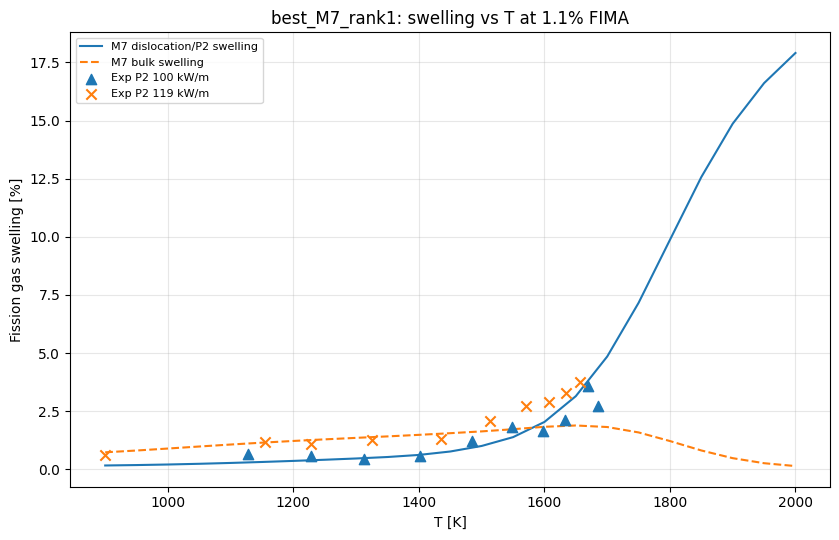

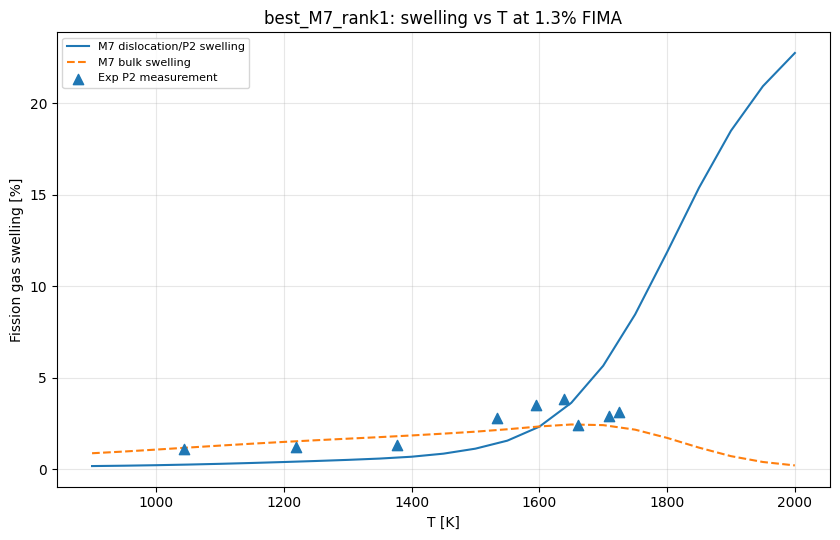

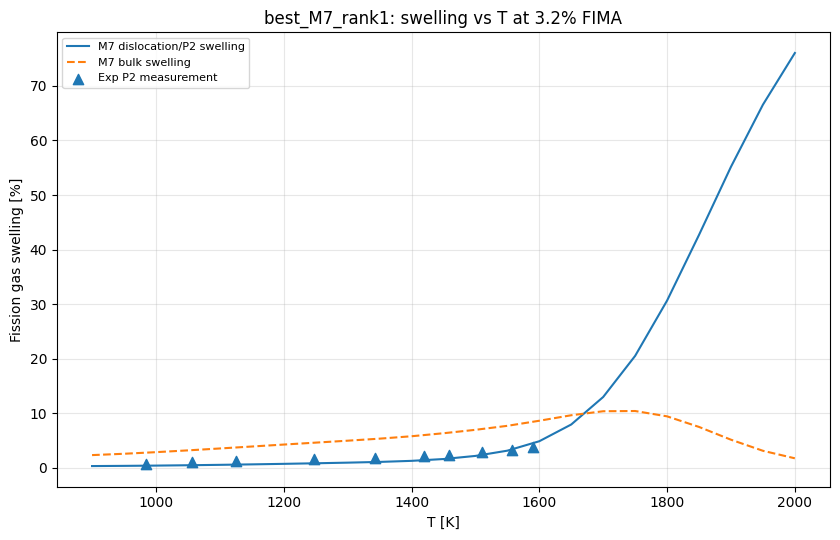

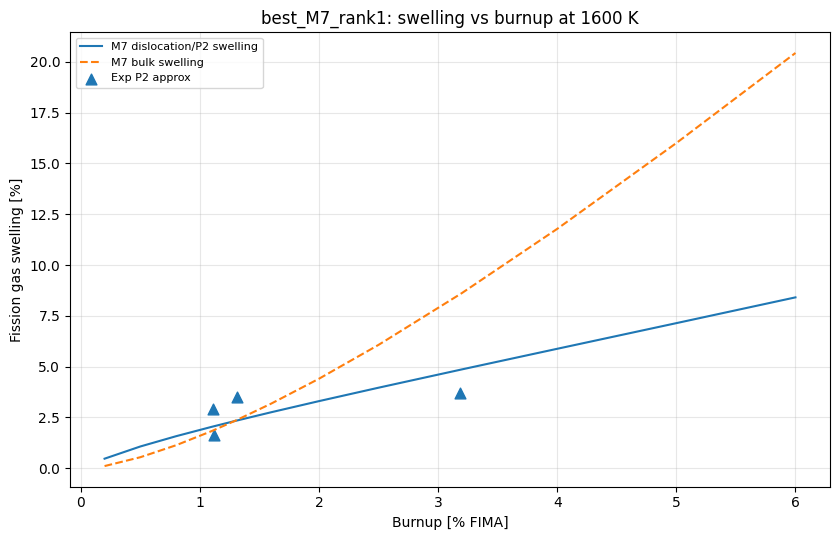

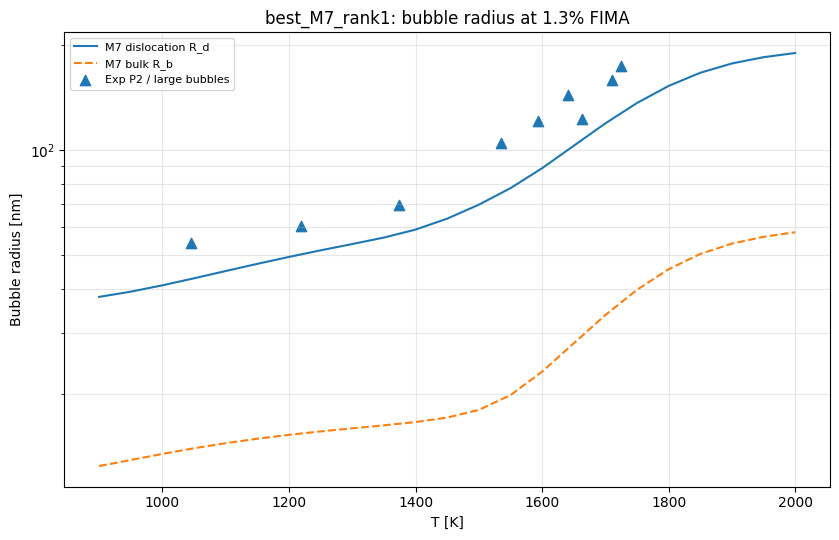

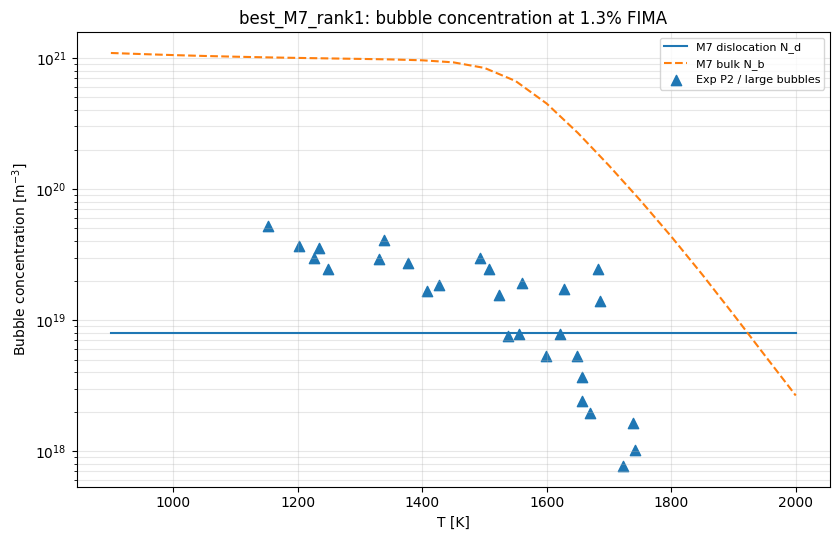

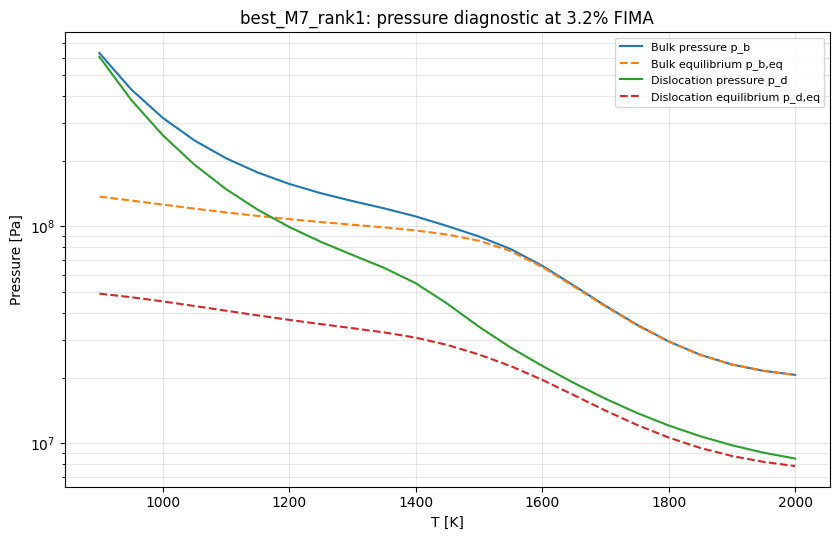

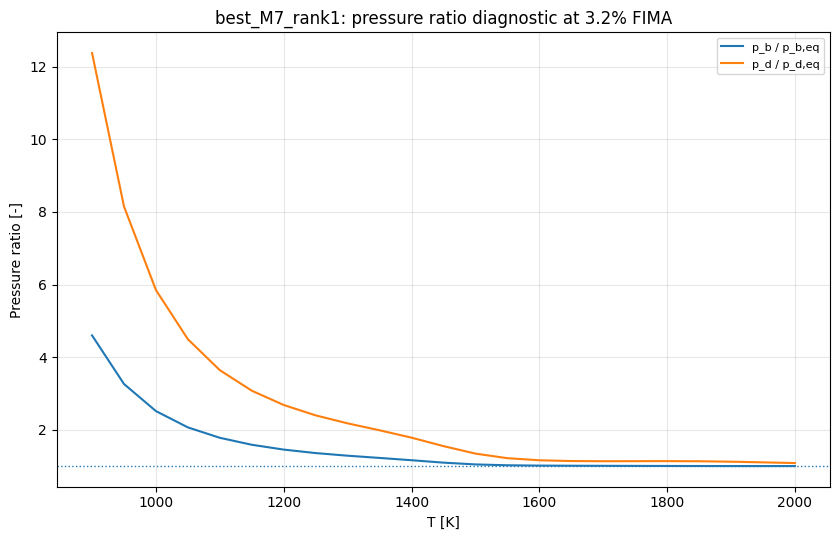

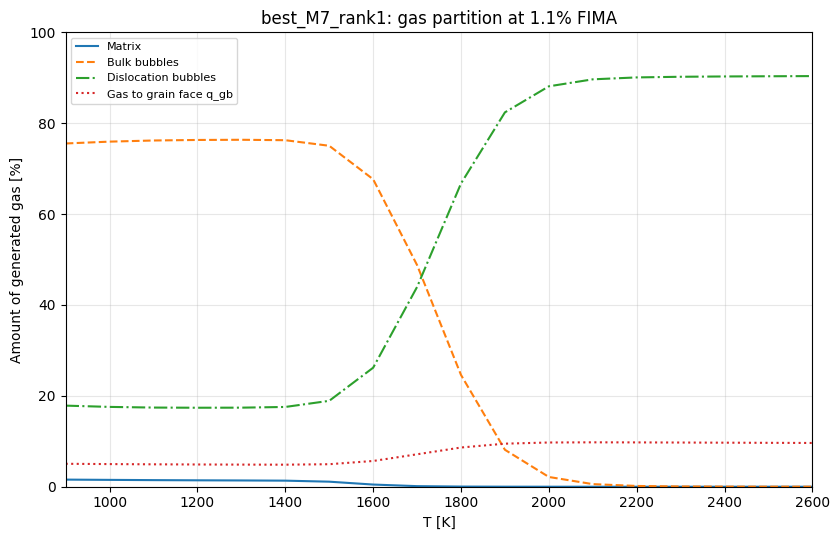

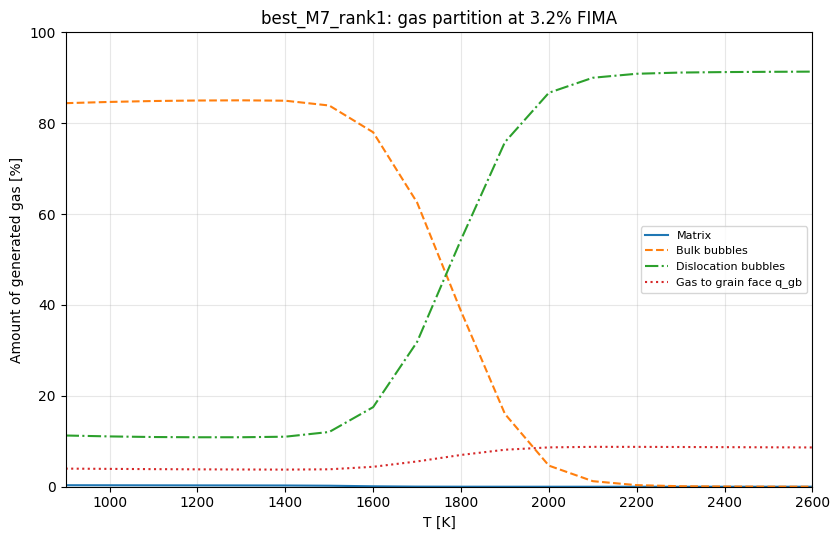

In [7]:
# M7 CELL 04 - PLOTS FOR BEST FINAL CANDIDATE
# Run after Cell 03. You can change PLOT_RANK to inspect another finalist.
# ============================================================

ensure_output_dir()
PLOT_RANK = 1   # 1 = best final, 2 = second, etc.

def _to_number_if_possible(x):
    if isinstance(x, (int, float)):
        return x
    try:
        s = str(x)
        if s.strip() == "":
            return x
        return float(s)
    except Exception:
        return x

def _load_scored_csv(path):
    if not os.path.exists(path):
        return []
    with open(path, newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    out = []
    for row in rows:
        out.append({k: _to_number_if_possible(v) for k, v in row.items()})
    return out

if "top_final_candidates" not in globals() or not top_final_candidates:
    top_final_candidates = _load_scored_csv(os.path.join(OUTPUT_DIR, "top_final_candidates.csv"))

if not top_final_candidates:
    raise RuntimeError("No final candidates found. Run Cell 03 first, or check results_M7_sweep/top_final_candidates.csv")

top_final_candidates = sorted(top_final_candidates, key=lambda r: float(r.get("score_total", math.inf)))
rank_index = max(0, min(PLOT_RANK - 1, len(top_final_candidates) - 1))
row = top_final_candidates[rank_index]
candidate_to_plot = candidate_from_row(row, f"_PLOT_rank{PLOT_RANK}")

print("Plotting candidate rank", PLOT_RANK)
print("label:", row.get("label"))
print("score_total:", row.get("score_total"))
print("f_n, K_d, rho_d, fission_rate:", row.get("f_n"), row.get("K_d"), row.get("rho_d"), row.get("fission_rate"))
print("scales Dg Dv b gb gd nu coal cap:", row.get("Dg_scale"), row.get("Dv_scale"), row.get("b_scale"), row.get("gb_scale"), row.get("gd_scale"), row.get("nu_scale"), row.get("coalescence_d_scale"), row.get("capture_scale"))

plot_best_candidate(candidate_to_plot, tag=f"best_M7_rank{PLOT_RANK}", dt_h=FINAL_DT_H, n_modes=FINAL_N_MODES)
